# Part 1

# TODO: Possibly add prediction error, check all parts are complete, figure out why line is below where it should be, verify in Colab


I used ChatGPT to understand the formulas given in the Linear Regression Optional Reading. I also used it to generate examples of linear regression from a theoretical standpoint in order to better understand the content. All code is my own

REPORT: 

I first spent time understanding linear regression better. I read through the optional reading multiple times, and I asked ChatGPT to explain the variables in the mathematical equation. It took some time before I understood the proof behind the given algorithm. After that, I wrote it in Python on my own. On my first attempt, I failed to sum the errors across all data points. After fixing that, the model still did not work. I checked each line individually and found that I accidentally subracted instead of added in one location. 

Final equation: h(x) = 6.43136169 + (47.79274105)x + (0.51861625)x^2  + -46.1759663x^3 + -7.90992137x^4 + 13.67842701x^5

I display several plots underneath my code, including the loss graph, slope and bias graphs, and the training and test data with the line of best fit marked. 

In [10]:
!pip install matplotlib
!pip install numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [13]:
# Define learn function
# deg is the highest degree of the function. Ex cubic function is 3
def learn(alpha, num_epoch, deg, x_train, y_train):
    # Check parameters
    if len(np.shape(y_train)) != 1: 
        raise ValueError(f"Invalid shape for y_train. Should be a flat array but received shape {np.shape(y_train)}")
    if len(np.shape(x_train)) != 2: 
        raise ValueError(f"Invalid shape for x_train. Should be a 2D array but received shape {np.shape(x_train)}")
    if type(alpha) != float:
        raise ValueError(f"Alpha should be a float but received a {type(alpha)}")
    if type(num_epoch) != int:
        raise ValueError(f"num_epoch should be an int but received a {type(num_epoch)}")
    if type(deg) != int:
        raise ValueError(f"deg should be an int but received a {type(deg)}")
        

    x_train = np.array(x_train)
    weight_history = []
    error_history = []

    # Each row of the weights corresponds to the degree (x^0, x^1, etc)
    # Each column correspoonds to an input variable column (first input column, second input column)
    weights_num_cols = np.shape(x_train)[1]
    weights_num_rows = deg + 1
    weights = np.zeros(shape=(weights_num_rows, weights_num_cols))
    w = 0
    while w < weights_num_cols and w < weights_num_rows:
        weights[w][w] = 1
        w = w + 1

    rand_adds = np.zeros_like(weights)
    rand_adds = np.random.random(np.shape(weights)) / 10 - 0.05
    weights = weights + rand_adds
    

    for j in tqdm(range(num_epoch)):
        # Calculate sum of loss
        loss_sum = 0
        for n in range(len(x_train)):
            exp_input_n = np.array([x_train[n] ** i for i in range(deg + 1)]) # The first row is for the bias value
            weighted_input_n = np.array(weights * exp_input_n)
            pred_val = np.sum(weighted_input_n) 
            loss = (y_train[n] - pred_val) * exp_input_n # A vector of loss for each parameter (weight and bias)

            loss_sum = loss_sum + loss

        error_history.append(np.sum(loss_sum))
        # Update theta
        weights = weights + alpha * loss_sum
        weight_history.append(weights)

    
    return weights, weight_history, error_history, loss_sum


In [14]:
# Load Data
x_train = np.load("x_train.npy")
y_train = np.load("y_train.npy")
x_test = np.load("x_test.npy")
y_test = np.load("y_test.npy")

In [15]:
x_train = np.reshape(x_train, (-1, 1))
print(x_train.shape)

(100, 1)


In [16]:
weights, weight_history, error_history, loss_sum = learn( 0.000001, 100000, 5, x_train, y_train)
print(f"Learned params: {weights}")

  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [03:28<00:00, 479.72it/s]

Learned params: [[  6.43136169]
 [ 47.79274105]
 [  0.51861625]
 [-46.1759663 ]
 [ -7.90992137]
 [ 13.67842701]]


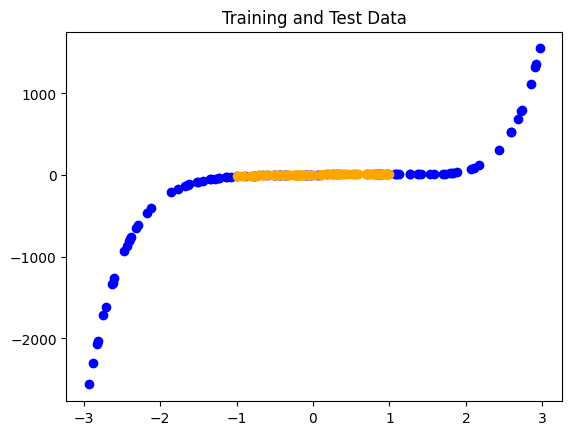

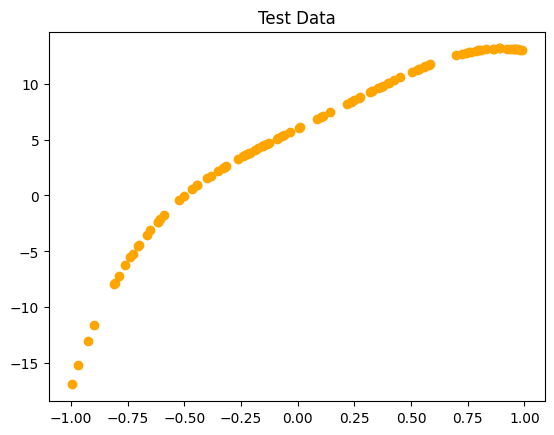

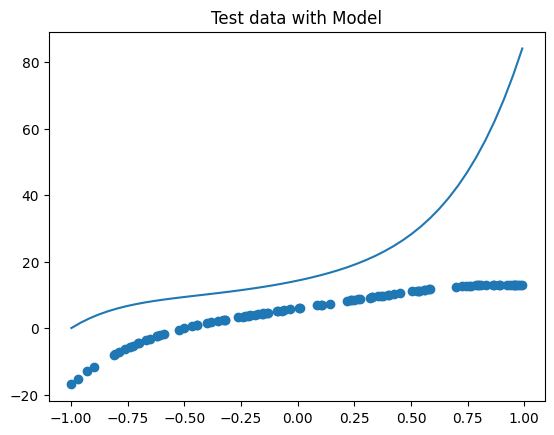

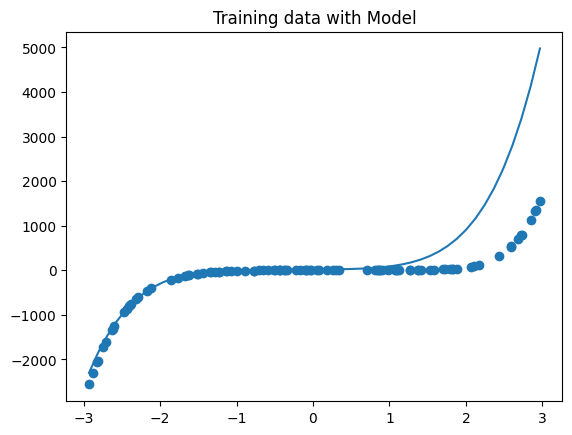

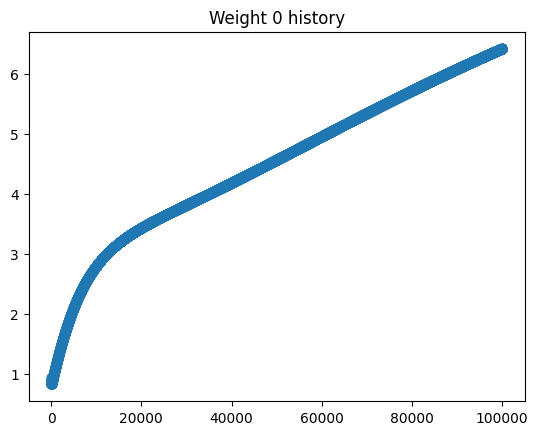

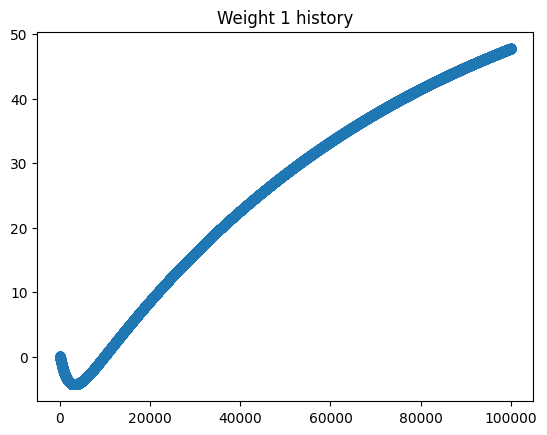

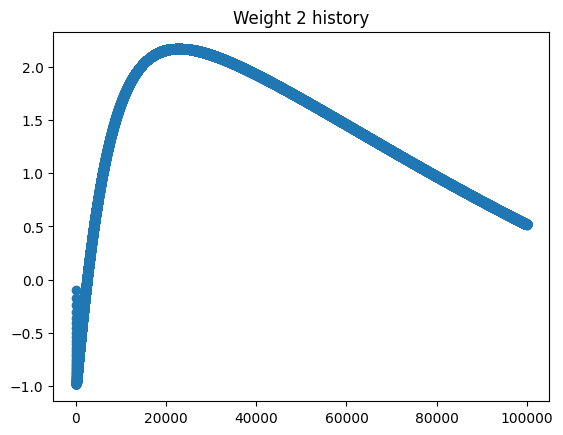

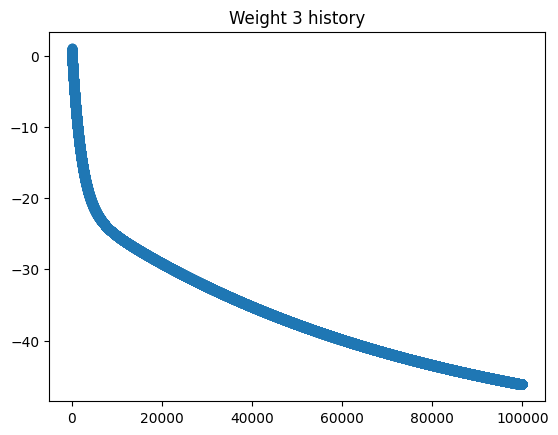

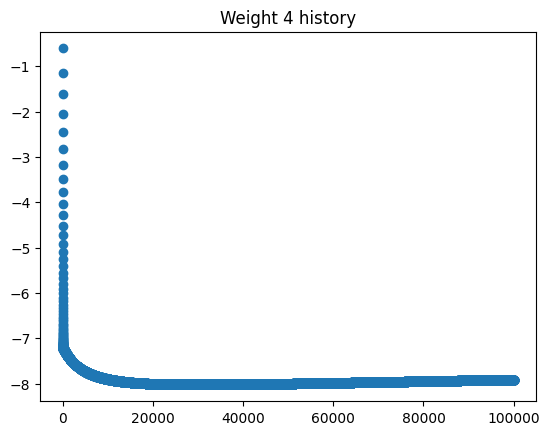

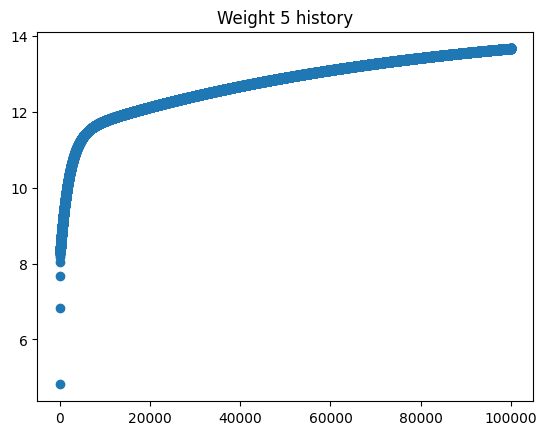

In [17]:
# Show results
plt.scatter(x_train, y_train, color="blue")
plt.scatter(x_test, y_test, color="orange")
plt.title("Training and Test Data")
plt.show()


plt.scatter(x_test, y_test, color="orange")
plt.title("Test Data")
plt.show()


plt.scatter(x_test, y_test)
x_space = np.linspace(np.min(x_test), np.max(x_test))
num_weights = len(weights)
model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
plt.plot(x_space, model_predictions)
plt.title("Test data with Model")
plt.show()

plt.scatter(x_train, y_train)
x_space = np.linspace(np.min(x_train), np.max(x_train))
num_weights = len(weights)
model_predictions =  [np.sum(weights * [x ** i for i in range(num_weights)]) for x in x_space]
plt.plot(x_space, model_predictions)
plt.title("Training data with Model")
plt.show()


# Plot history of each parameter
weight_history = np.array(weight_history)
for i in range(len(weights)):
    data = weight_history[:,i]
    plt.scatter([i for i in range(0, len(data))], data)
    plt.title(f"Weight {i} history")
    plt.show()


# Part 2

## Status: working on loading CSVs correctly, then planning on running "learn" function on one to get it to work, then find a way to return a predicted error or other metric and run on all in loop, and pick the best fit one

In [18]:
import matplotlib.pyplot as plt
import numpy as np

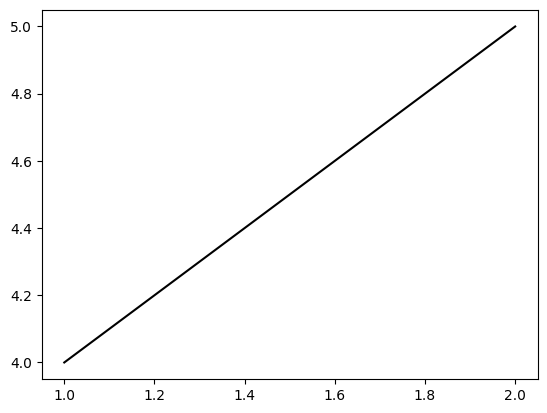

In [19]:

first_x = 1
last_x = 2
bias = 3
learned_slope = 1
plt.plot([first_x, last_x], [bias + first_x * learned_slope, bias + last_x * learned_slope], color="black")
plt.show()

In [20]:
data_formats = {'names': ('id', 'baths', 'land', 'living', 'garages', 'rooms','beds','age', 'price'), 'formats':('i2', 'f2', 'f4','f4', 'f4', 'i4', 'i4','i4','f8')}
housing_train = np.loadtxt("train.csv", delimiter=',', skiprows=1, dtype=data_formats)
housing_test = np.loadtxt("test.csv", delimiter=',', skiprows=1, dtype=data_formats)
#House ID,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Price

housing_train_output = housing_train["price"]

for n in data_formats["names"]:
    if n == 'price':
        continue
    print("\n\n", n)
    housing_train_input = housing_train[n]

    learned_slope, bias, slope_history, bias_history, error_history, final_loss = learn( 0.000001, 200, housing_train_input, housing_train_output)
    print(f"Learned slope: {learned_slope}")
    print(f"Learned bias: {bias}")
    print(f"Equation: h(x) = {learned_slope}x + {bias}")
    print(f"Loss is {final_loss}")

    plt.scatter(housing_train_input, housing_train_output)
    first_x = np.min(housing_train_input)
    last_x = np.max(housing_train_input)
    plt.plot([first_x, last_x], [bias - first_x * learned_slope, bias + last_x * learned_slope], color="black")
    plt.title(f"Price vs {n}")
    plt.show()



 id


TypeError: learn() missing 1 required positional argument: 'y_train'